In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle as pkl

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

## Loading and preprocessing ENEM dataset

In [9]:
# first create the "clean pool" of applicants
df = pd.read_csv("data/MICRODADOS_ENEM_2020.csv", encoding="cp860", sep=";")

df = df[df["SG_UF_PROVA"] == "SP"]

# drop rows with no NU_NOTA_LC
df = df.dropna(subset=["NU_NOTA_LC"])

# consider only 6 classes of age by removing individuals for higher class
df = df[df["TP_FAIXA_ETARIA"] <= 14]
df["TP_FAIXA_ETARIA"] = df["TP_FAIXA_ETARIA"].apply(lambda x : (x - 1) // 7)
#df["TP_FAIXA_ETARIA"] = df["TP_FAIXA_ETARIA"].apply(lambda x : min(x, 6))


df = df.sample(10_000, random_state=42)
# I will consider the score in portuguese test
df["target"] = df["NU_NOTA_LC"]
df["TP_DEPENDENCIA_ADM_ESC"] = df["TP_DEPENDENCIA_ADM_ESC"].fillna(-1)

In [10]:
columns_to_drop = [
    "NU_INSCRICAO",
    "NU_ANO",
    "CO_MUNICIPIO_ESC",
    "NO_MUNICIPIO_ESC",
    "CO_UF_ESC",
    "CO_MUNICIPIO_PROVA",
    'NO_MUNICIPIO_PROVA',
    'CO_UF_PROVA',
    'SG_UF_PROVA',
    'TP_PRESENCA_CN',
    'TP_PRESENCA_CH',
    'TP_PRESENCA_LC',
    'TP_PRESENCA_MT',
    'CO_PROVA_CN',
    'CO_PROVA_CH',
    'CO_PROVA_LC',
    'CO_PROVA_MT',
    'NU_NOTA_CN',
    'NU_NOTA_CH',
    'NU_NOTA_LC',
    'NU_NOTA_MT',
    'TX_RESPOSTAS_CN',
    'TX_RESPOSTAS_CH',
    'TX_RESPOSTAS_LC',
    'TX_RESPOSTAS_MT',
    'TX_GABARITO_CN',
    'TX_GABARITO_CH',
    'TX_GABARITO_LC',
    'TX_GABARITO_MT',
    'TP_STATUS_REDACAO',
    'NU_NOTA_COMP1',
    'NU_NOTA_COMP2',
    'NU_NOTA_COMP3',
    'NU_NOTA_COMP4',
    'NU_NOTA_COMP5',
    'NU_NOTA_REDACAO',
    "TP_NACIONALIDADE",
    "SG_UF_ESC",
]

In [11]:
df = df.drop(columns = columns_to_drop)
for col in ["TP_LOCALIZACAO_ESC", "TP_SIT_FUNC_ESC", "TP_ENSINO"]:
        df[col] = df[col].fillna("Unknown")

df["TP_FAIXA_ETARIA"] = df["TP_FAIXA_ETARIA"] - 1

# convert all columns to str
df["TP_COR_RACA"] = df["TP_COR_RACA"].apply(lambda x : x == 1)
for col in df.columns:
    df[col] = df[col].apply(str)
df["target"] = df["target"].astype(float)

# make first column be "TP_COR_RACA" followed by "TP_FAIXA_ETARIA"
remaining_columns = [col for col in df.columns if col not in ["TP_COR_RACA", "TP_FAIXA_ETARIA"]]
df = df[["TP_COR_RACA", "TP_FAIXA_ETARIA"] + remaining_columns]
df["target"] = df["target"].apply(lambda x : 1 if x > 575 else 0)

## Transform all columns in numerical

In [12]:
Z = df["TP_COR_RACA"].apply(lambda x : 1. if x == "True" else 0.).values
X_age = df["TP_FAIXA_ETARIA"].apply(lambda x : int(x))
X = df.drop(columns=["target", "TP_COR_RACA", "TP_FAIXA_ETARIA"])
y = df["target"]

print("Positive rate:", np.mean(y))

Positive rate: 0.3825


In [13]:
one_hot = OneHotEncoder(sparse_output=False)
X_age = one_hot.fit_transform(X_age.values.reshape(-1, 1))
one_hot = OneHotEncoder(sparse_output=False, handle_unknown="infrequent_if_exist", min_frequency=0.1)
X = one_hot.fit_transform(X)

In [14]:
# create columns that are the interaction of Z and X_change
nc = X_age.shape[1]
X_interaction = np.zeros((X_age.shape[0], 2 * nc)) 

# The first nc columns are related to Z = 0 and the second nc columns are related to Z = 1
 
for i in range(X_age.shape[0]):
    z = Z[i]
    if z == 0:
        X_interaction[i, :nc] = X_age[i, :]
    else:
        X_interaction[i, nc:] = X_age[i, :]

## Fit a model that simulates $\alpha(x, z)$

In [15]:
#X_data = np.concatenate([passed, Z.reshape(-1, 1), X_interaction, X], axis=1)
#X_data = np.concatenate([Z.reshape(-1, 1), X_interaction, X], axis=1)
X_data = np.concatenate([Z.reshape(-1, 1), X_age, X], axis=1)
model = LogisticRegression(max_iter=1000, random_state=42) #, class_weight={0:1, 1: 2})

X_train, X_test, y_train, y_test, z_train, z_test = train_test_split(X_data, y, Z, test_size=0.2, random_state=42)

# create sample weight that is equal to the number of samples in each group
#nz0 = np.sum(z_train == 0)
#nz1 = np.sum(z_train == 1)
#sample_weight = np.array([1 / nz1 if z == 0 else 1 / nz0 for z in z_train])

# create sample weight equal to 2 for positive class and 1 for negative class
#sample_weight = np.array([2 if y == 1 else 1 for y in y_train])

model.fit(X_train, y_train) #, sample_weight=sample_weight)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print(f"Positive rate in predictions: {np.mean(y_pred):.2f}")

Accuracy: 0.67
Positive rate in predictions: 0.31


In [16]:
for i in range(2):
    print(f"Group {i} probability:\t {np.mean(Z == i):.2f}")
    print(f"Group {i} accuracy:\t {accuracy_score(y_test[z_test == i], y_pred[z_test == i]):.2f}")
    print(f"Group {i} positive rate:\t {np.mean(y_pred[z_test == i]):.2f}")
    print("")

Group 0 probability:	 0.41
Group 0 accuracy:	 0.71
Group 0 positive rate:	 0.13

Group 1 probability:	 0.59
Group 1 accuracy:	 0.65
Group 1 positive rate:	 0.44



## Visualize model

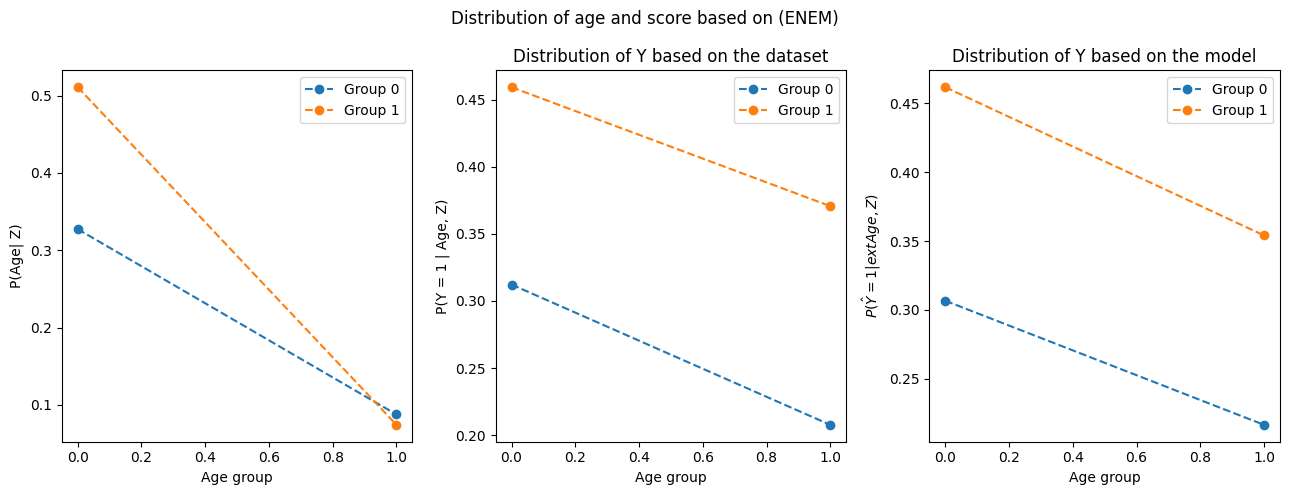

<Figure size 640x480 with 0 Axes>

In [17]:
# bar plot of target grouped by "TP_COR_RACA"

fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize = (13, 5))

plt.suptitle("Distribution of age and score based on (ENEM)")

for i in range(2):
    group_counts = X_interaction[:, (nc * i) : (nc * (i + 1))]
    group_counts = np.mean(group_counts, axis = 0)
    axs[0].plot(group_counts, linestyle = "--", marker = "o", label = f"Group {i}")


axs[0].set_ylabel("P(Age| Z)")


for i in range(2):
    p_y = np.zeros(nc)
    for c in range(nc):
        p_y[c] = np.mean(y[(Z == i) & (X_age[:, c] == 1)])

    axs[1].plot(p_y, linestyle = "--", marker = "o",  label = f"Group {i}")

axs[1].set_ylabel("P(Y = 1 | Age, Z)")
axs[1].set_title("Distribution of Y based on the dataset")


predictions = model.predict_proba(X_data)[:, 1]

# calculate predictions per group and age
for i in range(2):
    p_y = np.zeros(nc)
    for c in range(nc):
        p_y[c] = np.mean(predictions[(Z == i) & (X_age[:, c] == 1)])

    axs[2].plot(p_y, linestyle = "--", marker = "o",  label = f"Group {i}")

#coef_groups = model.coef_[0][3:2*nc+3].reshape(2, nc)

#for i in range(2):
#    axs[2].plot(coef_groups[i], label=f"Group {i}", linestyle='--', marker="o")


for i in range(3):
    axs[i].set_xlabel("Age group")
    axs[i].legend()

axs[2].set_ylabel("$P(\hat Y = 1 | \text{Age}, Z)$")
axs[2].set_title("Distribution of Y based on the model")

plt.tight_layout()
plt.show()

plt.savefig("figures/enem1.pdf", bbox_inches='tight')
plt.show()

## Save the pool and model on disk

In [88]:
pool = []

for i in range(X_data.shape[0]):
    #p = model.predict_proba(X_data[i, :].reshape(1, -1))[0, 1]
    #y_ = 1 if np.random.rand() < p else 0
    #g = np.zeros(2)
    #g[int(Z[i])] = 1
    features = np.concatenate([X_data[i], [0]]).astype(np.float32)
    pool.append({
        "features" : features,
        "group" : Z[i],
    })
    
with open("data/enem_pool.pkl", "wb") as f:
    pkl.dump(pool, f)

with open("data/enem_model.pkl", "wb") as f:
    pkl.dump(model, f)
